# Networks

### Imports

In [1]:
import sys
sys.path.append("..")

import random

from networks.bst_network import BinarySearchTreeNetwork
from networks.optimal_network import build_optimal_bst_network
from networks.optimal_network import requests_to_matrix
from networks.splaynet import SplayNet

from workloads.uniform import generate_random_requests
from workloads.hot_set import generate_hotset_requests
from workloads.temporal import generate_temporal_requests

from visualization.results_visualization import plot_network_metrics

### Functions

In [2]:
def test_networks(n, requests, repeat=10, verbose=True):
    """
    Compare the performance of a BST network, an optimal BST network,
    and SplayNet.

    The BST network and SplayNet are initialized from independently
    shuffled insertion orders. Their performance metrics are averaged
    over the specified number of repetitions.

    Args:
        n: Number of network nodes.
        requests: Sequence of communication requests.
        repeat: Number of independent repetitions used for averaging.
        verbose: Whether summary statistics should be printed.

    Returns:
        A tuple containing:

        - average BST network communication cost history,
        - optimal BST network communication cost history,
        - average SplayNet communication cost history,
        - average SplayNet rotation count history.
    """

    bst_network_communication_cost = [0 for _ in range(len(requests))]
    optimal_bst_network_communication_cost = [0 for _ in range(len(requests))]
    splaynet_communication_cost = [0 for _ in range(len(requests))]
    splaynet_rotations = [0 for _ in range(len(requests))]

    request_matrix = requests_to_matrix(n, requests)
    optimal_bst_network = build_optimal_bst_network(request_matrix)

    for i, (sender, receiver) in enumerate(requests):
        optimal_bst_network.request(sender, receiver)
        optimal_bst_network_communication_cost[i] = (optimal_bst_network.total_communication_cost)

    for _ in range(repeat):
        bst_network = BinarySearchTreeNetwork()
        splaynet = SplayNet()

        keys = list(range(n))
        random.shuffle(keys)

        for key in keys:
            bst_network.insert(key)
            splaynet.insert(key)

        for i, (sender, receiver) in enumerate(requests):
            bst_network.request(sender, receiver)
            splaynet.request(sender, receiver)

            bst_network_communication_cost[i] += bst_network.total_communication_cost
            splaynet_communication_cost[i] += splaynet.total_communication_cost
            splaynet_rotations[i] += splaynet.rotations

    bst_network_communication_cost = [x / repeat for x in bst_network_communication_cost]
    splaynet_communication_cost = [x / repeat for x in splaynet_communication_cost]
    splaynet_rotations = [x / repeat for x in splaynet_rotations]

    if verbose:
        print("Optimal BST Network Communication Cost:", int(optimal_bst_network_communication_cost[-1]))
        print("BST Network Average Communication Cost:", int(bst_network_communication_cost[-1]))
        print("SplayNet Average Communication Cost:", int(splaynet_communication_cost[-1]))
        print("SplayNet Average Rotation Count:", int(splaynet_rotations[-1]))

    return (
        bst_network_communication_cost,
        optimal_bst_network_communication_cost,
        splaynet_communication_cost,
        splaynet_rotations,
    )


### Uniform Distribution

Optimal BST Network Communication Cost: 73095
BST Network Average Communication Cost: 92872
SplayNet Average Communication Cost: 10000
SplayNet Average Rotation Count: 98621


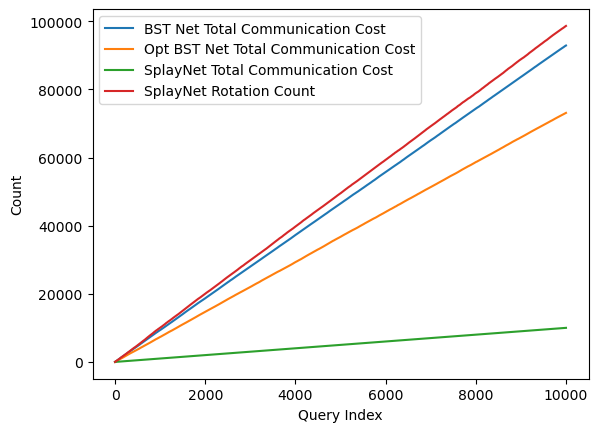

In [3]:
requests = generate_random_requests(100, 10000, 2)

bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations = test_networks(100, requests, 10, True)
plot_network_metrics(bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations)

### Hot Set

**hot_fraction = 0.1** \
**hot_probability = 0.9**

Optimal BST Network Communication Cost: 32243
BST Network Average Communication Cost: 93264
SplayNet Average Communication Cost: 10000
SplayNet Average Rotation Count: 39868


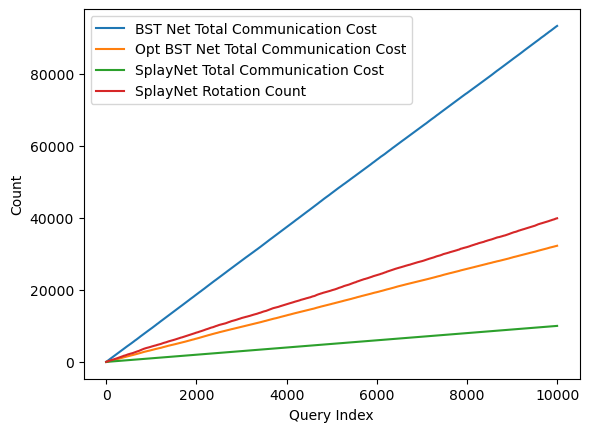

In [4]:
requests = generate_hotset_requests(100, 10000, 0.1, 0.9, 2)

bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations = test_networks(100, requests, 10, True)
plot_network_metrics(bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations)

**hot_fraction = 0.3** \
**hot_probability = 0.9**

Optimal BST Network Communication Cost: 32287
BST Network Average Communication Cost: 101199
SplayNet Average Communication Cost: 10000
SplayNet Average Rotation Count: 38643


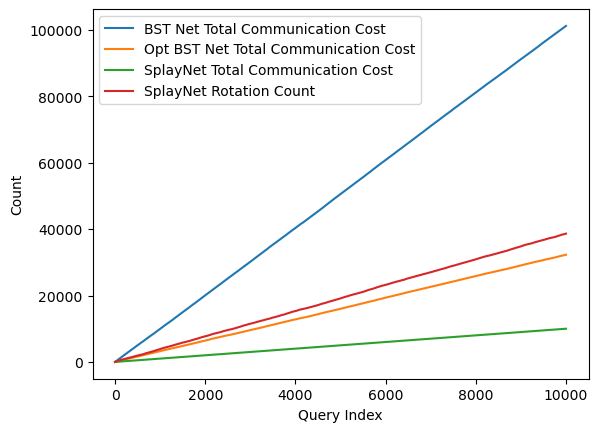

In [5]:
requests = generate_hotset_requests(100, 10000, 0.1, 0.9, 2)

bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations = test_networks(100, requests, 10, True)
plot_network_metrics(bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations)

**hot_fraction = 0.5** \
**hot_probability = 0.9**

Optimal BST Network Communication Cost: 58901
BST Network Average Communication Cost: 95212
SplayNet Average Communication Cost: 10000
SplayNet Average Rotation Count: 79558


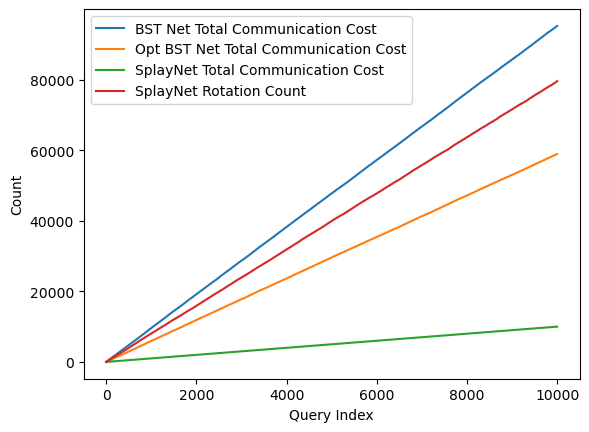

In [6]:
requests = generate_hotset_requests(100, 10000, 0.5, 0.9, 2)

bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations = test_networks(100, requests, 10, True)
plot_network_metrics(bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations)

### Temporal Locality

**p_repeat = 0.5**

Optimal BST Network Communication Cost: 72340
BST Network Average Communication Cost: 95852
SplayNet Average Communication Cost: 10000
SplayNet Average Rotation Count: 50009


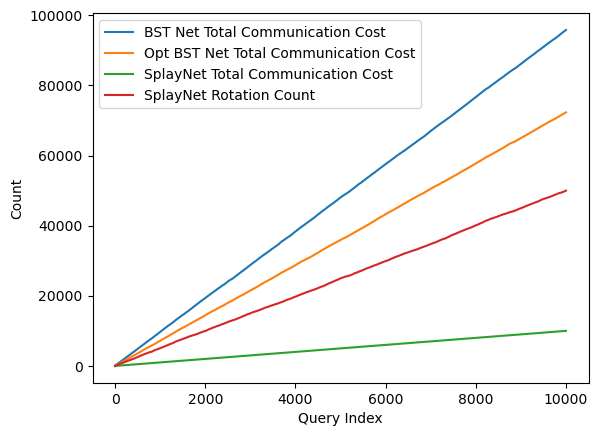

In [7]:
requests = generate_temporal_requests(100, 10000, p_repeat=0.5, dim=2)

bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations = test_networks(100, requests, 10, True)
plot_network_metrics(bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations)

**p_repeat = 0.9**

Optimal BST Network Communication Cost: 70180
BST Network Average Communication Cost: 97858
SplayNet Average Communication Cost: 10000
SplayNet Average Rotation Count: 9934


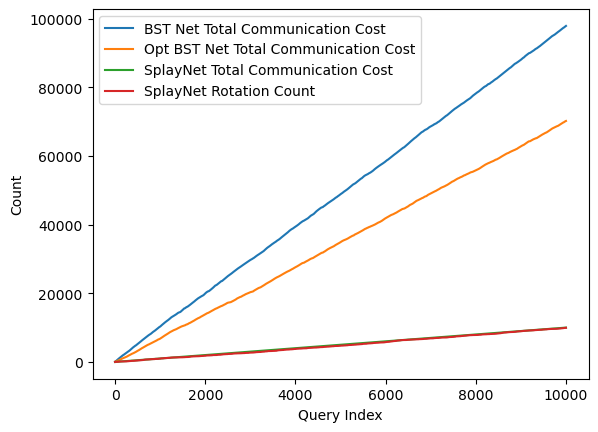

In [8]:
requests = generate_temporal_requests(100, 10000, p_repeat=0.9, dim=2)

bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations = test_networks(100, requests, 10, True)
plot_network_metrics(bst_network_communication_cost, optimal_bst_network_communication_cost, splaynet_communication_cost, splaynet_rotations)